# CO5420 Air Pollution Forecasting

## 03 — LSTM Experiment

## tl;dr

The LSTM achieved validation RMSE `15.6505` and local-test RMSE
`25.9367`. It outperformed the equivalent GRU on both splits and
obtained the lowest local-test MAE (`11.4252`) among the individual
neural models. Its complementary errors later made it useful in
the final ensemble.

## Context & Methods

The LSTM processes the temporal input directly:

```text
Input(24, 43)
→ LSTM(64)
→ Layer normalisation
→ Dropout(0.20)
→ Dense(32, ReLU)
→ Dropout(0.10)
→ Dense(1, Linear)
```

Training uses Adam, mean squared error, gradient clipping,
validation-based checkpoint selection, early stopping, and
learning-rate reduction. Seed 42 is used for the primary
architecture comparison.

### Key Assumptions

- Input windows remain within one station and contain 24
  consecutive hours.
- Validation and local-test targets never enter training.
- Negative predictions are clipped to zero only for evaluation.

## Data

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

METRICS_DIR = PROJECT_ROOT / "results" / "metrics"
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

print(f"Project root: {PROJECT_ROOT}")
print(f"Metrics directory exists: {METRICS_DIR.exists()}")

Project root: /mnt/c/Users/wijer/Documents/GitHub/co-5420-air-pollution
Metrics directory exists: True


In [2]:
recurrent_metrics = pd.read_csv(
    METRICS_DIR / "recurrent_metrics.csv"
)
lstm_history = pd.read_csv(
    METRICS_DIR / "lstm_training_history.csv"
)
station_metrics = pd.read_csv(
    METRICS_DIR / "recurrent_station_metrics.csv"
)
range_metrics = pd.read_csv(
    METRICS_DIR / "recurrent_pollution_range_metrics.csv"
)

lstm_metrics = (
    recurrent_metrics.loc[
        recurrent_metrics["model"] == "lstm"
    ]
    .sort_values("split")
    .reset_index(drop=True)
)
assert len(lstm_metrics) == 2
assert int(lstm_metrics["parameters"].iloc[0]) == 29_889
display(lstm_metrics)

,model,split,samples,epochs_trained,best_epoch,parameters,training_seconds,rmse,mae,r2
0,lstm,local_test,25891,27,19,29889,132.4816,25.9367,11.4252,0.9485
1,lstm,validation,25458,27,19,29889,132.4816,15.6505,8.3936,0.9680


## Results

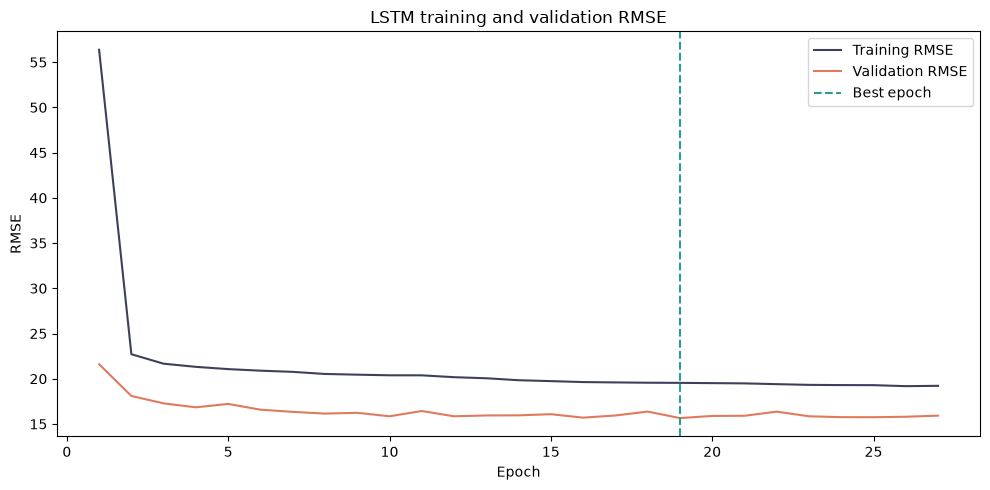

In [3]:
axis = lstm_history.plot(
    x="epoch",
    y=["rmse", "val_rmse"],
    figsize=(10, 5),
    color=["#3D405B", "#E07A5F"],
)
axis.axvline(
    int(lstm_metrics["best_epoch"].iloc[0]),
    linestyle="--",
    color="#2A9D8F",
    label="Best epoch",
)
axis.set_title("LSTM training and validation RMSE")
axis.set_xlabel("Epoch")
axis.set_ylabel("RMSE")
axis.legend(["Training RMSE", "Validation RMSE", "Best epoch"])
plt.tight_layout()
plt.show()

### Comparison with the equivalent GRU

In [4]:
recurrent_comparison = recurrent_metrics.pivot(
    index="model",
    columns="split",
    values=["rmse", "mae", "r2"],
).sort_values(("rmse", "validation"))
display(recurrent_comparison)

rmse                   mae                    r2           
split local_test validation local_test validation local_test validation
model                                                                  
lstm     25.9367    15.6505    11.4252     8.3936     0.9485     0.9680
gru      27.4224    16.0906    11.8377     8.4478     0.9424     0.9662

### Error variation by station and pollution range

In [5]:
lstm_local_stations = (
    station_metrics.loc[
        (station_metrics["model"] == "lstm")
        & (station_metrics["split"] == "local_test")
    ]
    .sort_values("rmse")
    [["station", "samples", "rmse", "mae", "r2"]]
)
lstm_local_ranges = (
    range_metrics.loc[
        (range_metrics["model"] == "lstm")
        & (range_metrics["split"] == "local_test")
    ]
    [["pollution_range", "samples", "rmse", "mae", "r2"]]
)

print("LSTM local-test station performance")
display(lstm_local_stations)
print("LSTM local-test performance by PM2.5 range")
display(lstm_local_ranges)

LSTM local-test station performance


,station,samples,rmse,mae,r2
31,Nongzhanguan,2170,21.8688,11.3537,0.9666
30,Huairou,2136,22.0744,10.0980,0.9484
28,Guanyuan,2172,22.7327,10.8582,0.9616
25,Changping,2158,25.3779,10.8644,0.9184
24,Aotizhongxin,2161,25.6676,11.3244,0.9524
29,Gucheng,2164,25.9364,12.6251,0.9529
27,Dongsi,2173,25.9873,12.0334,0.9557
33,Tiantan,2167,26.0761,11.8316,0.9510
34,Wanliu,2167,26.1768,10.7319,0.9471
32,Shunyi,2157,27.3921,12.2493,0.9481


LSTM local-test performance by PM2.5 range


,pollution_range,samples,rmse,mae,r2
10,0-35,12772,7.6836,4.2022,0.0465
11,150-250,2868,28.4671,19.1846,0.0400
12,250+,2247,70.6474,39.0998,0.6395
13,35-75,3773,15.9612,10.4341,-0.9283
14,75-150,4246,22.6380,14.1774,-0.1330


## Takeaways

- The LSTM is the strongest individual recurrent model.
- Validation RMSE is slightly lower than the feedforward network,
  while local-test RMSE is slightly higher.
- Its lower local-test MAE indicates good performance on typical
  observations, although large errors still dominate RMSE during
  severe-pollution periods.
- The LSTM and feedforward models make sufficiently different
  errors to justify validation-only ensemble testing.

Reproduce the recurrent experiment:

```bash
conda activate co5420-air-gpu
python -m scripts.train_recurrent_models
```